# DATA INGESTION

* Loader

In [1]:
from langchain_community.document_loaders import PyPDFLoader,DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [2]:
dir_loader_pdf=DirectoryLoader(
    "../data/pdf",
    glob="**/*.pdf",
    loader_cls=PyPDFLoader,
    show_progress=True
)

* CHUNKS

In [3]:
class Text_Chunker:
    def __init__(self,chunk_size=800,chunk_overlap=100):
        self.splitter=RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=["\n\n", "\n", ".", " "]

        )
        
    def split(self,documents):
        chunks=self.splitter.split_documents(documents)
        
        for i,chunk in enumerate(chunks):
            chunk.metadata["chunk_id"]=i
        return chunks    
documents=dir_loader_pdf.load()

chunker=Text_Chunker(chunk_size=800,chunk_overlap=100)

chunks=chunker.split(documents)
chunks


        



100%|██████████| 8/8 [00:02<00:00,  3.00it/s]


[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-03-24T23:30:31+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-03-24T23:30:31+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '..\\data\\pdf\\01_Recruitment_and_Hiring_Policy.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1', 'chunk_id': 0}, page_content='Recruitment & Hiring Policy\n End-to-End Talent Acquisition Guidelines\n Doc ID: HR-001 | Version 1.0 | TalentIQ HR Solutions\n1. Purpose & Scope\nThis policy establishes a fair, transparent, and consistent recruitment process for all positions within the\norganization. It applies to all hiring managers, HR personnel, and external recruitment agencies involved in\ntalent acquisition.\n2. Recruitment Process\n2.1 Job Requisition\nAll new hires must be initiated through a formal Job Requisition Form (JRF) approved by the department\nhead and HR Director 

In [4]:
print(f"Total Chunks: {len(chunks)}")

Total Chunks: 42


* Embedding

In [5]:
import numpy as np
from sentence_transformers import SentenceTransformer
from typing import List,Dict,Any,Type,Tuple

d:\My Projectss\TalentIq\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
class Embedding:
    __model=None
    
    def __init__(self,model_name="all-MiniLM-L6-v2"):
        self.model_name=model_name
        
        if Embedding.__model is None:
            print("Load Embedding.....")
            Embedding.__model=SentenceTransformer(self.model_name)
        
        self.model=Embedding.__model
        
    def get_embedding(self,text:str)->np.ndarray:
        return self.model.encode(text,show_progress_bar=True)

embedding_manager=Embedding()
embedding_manager

Load Embedding.....


* Vector Store

In [ ]:
# --- 1. WRAPPER CLASS (FIXED WITH __call__) ---
class LangChainEmbeddingWrapper:
    """FAISS ko aapki custom Embedding class ke sath compatible banane ke liye wrapper."""
    def __init__(self, embedding_manager_instance):
        self.manager = embedding_manager_instance

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        embeddings = self.manager.model.encode(texts, show_progress_bar=False)
        return [e.tolist() for e in embeddings]

    def embed_query(self, text: str) -> list[float]:
        embedding = self.manager.model.encode(text, show_progress_bar=False)
        return embedding.tolist()

    def __call__(self, text: str) -> list[float]:
        """LangChain FAISS calling support."""
        return self.embed_query(text)

In [ ]:
import os
from langchain_community.vectorstores import FAISS
    
class VectorStore:
    """Managing the embeddings into a vector store."""
    def __init__(self, embedding_manager, persist_directory: str = "../data/faiss_index"):
        self.persist_directory = persist_directory
        # FIX: Yahan direct aapki wrapper class call hogi jo aapne oopar banai hui hai
        self.embedding_wrapper = LangChainEmbeddingWrapper(embedding_manager)
        self.faiss_index = None
        
    def create_and_save_store(self, chunks):
        print("Creating Faiss Index...")
        os.makedirs(self.persist_directory, exist_ok=True)
        
        # Ab FAISS ko wrapper milay ga toh error nahi aye ga
        self.faiss_index = FAISS.from_documents(chunks, self.embedding_wrapper)
        
        self.faiss_index.save_local(self.persist_directory)
        print(f"✓ Faiss Index saved at: {self.persist_directory}")
        return self.faiss_index  
        
    def load_store(self):
        """Agar database pehle se bana ho toh usay load karne ke liye."""
        if os.path.exists(os.path.join(self.persist_directory, "index.faiss")):
            self.faiss_index = FAISS.load_local(
                self.persist_directory,
                self.embedding_wrapper,
                allow_dangerous_deserialization=True 
            )
            print("FAISS STORE loaded Successfully")
            return self.faiss_index
        else:
            print(" No existing FAISS index found.")
            return None

In [45]:
db_manager = VectorStore(embedding_manager=embedding_manager, persist_directory="../data/faiss_index")
faiss_db = db_manager.create_and_save_store(chunks)
retriever = faiss_db.as_retriever(search_kwargs={"k": 3})

Creating Faiss Index...


`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


✓ Faiss Index saved at: ../data/faiss_index


In [46]:
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile",temperature=0.2,api_key=os.getenv("GROQ_API_KEY"))


# State Defination

In [47]:
from typing import TypedDict,List
from langchain_core.documents import Document
class AgentState(TypedDict):
    question:str
    documents:List[Document]
    answer:str
    needs_retrievel:bool

In [48]:
def decide_retrieval(state:AgentState)->AgentState:
    """
    Decide if we need to retrieve document based on the question
    """
    question=state["question"]
    
    #simple heuristic= if question contain certain keyword,retrieve
    retrieval_keywords=["what","how","explain","describe","Tell me"]
    needs_retrieval=any(keyword in question.lower() for keyword in retrieval_keywords)
    
    return {**state,"needs_retrievel":needs_retrieval}

In [49]:
def retrieve_document(state:AgentState)->AgentState:
    """
    Retrieve Relevant Document Based On the Question
    """
    question=state["question"]
    documents=retriever.invoke(question)
    return {**state,"documents":documents}

In [50]:
def generate_answer(state:AgentState)->AgentState:
    """
    Generate an Answer using retrieved docs or direct response
    """
    question=state["question"]
    documents=state.get("documents",[])
    
    if documents:
        # Generate answer using retrieved documents
        context="\n\n".join([doc.page_content for doc in documents])
        prompt=f"""based on the following context,answer the question:
Context:{context}
Question:{question}

Answer: """

    else:
        #Generate answer withour retrieved documents
        prompt=f"Answer the following question:{question}"
    response=llm.invoke(prompt)
    answer=response.content
    return {**state,"answer":answer}


# Conditional Logic

In [51]:
def should_retrieve(state:AgentState)->AgentState:
    """
    Decide if we need to retrieve document based on the question
    """
    if state["needs_retrievel"]:
        return "retrieve"
    else:
        return "generate"


# Build the Graph

 Agentic RAG Graph Compiled Successfully!


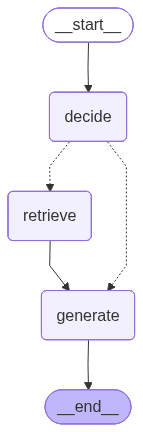

In [52]:
#Cretae state Graph

from langgraph.graph import StateGraph,START,END
workflow=StateGraph(AgentState)


workflow.add_node("decide",decide_retrieval)
workflow.add_node("retrieve",retrieve_document)
workflow.add_node("generate",generate_answer)

workflow.set_entry_point("decide")

workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve":"retrieve",
        "generate":"generate"
    }
)
workflow.add_edge("retrieve","generate")
workflow.add_edge("generate",END)

app=workflow.compile()
print(" Agentic RAG Graph Compiled Successfully!")
app



# Test the agent

In [53]:
def ask_question(question:str)->str:
    """
    helper function to ask question to the agent and get answer
    """
    initial_state={
        "question":question,
        "documents":[],
        "answer":"",
        "needs_retrievel":False,
    }
    result=app.invoke(initial_state)
    return result

In [65]:
question1="whats the real answer of why should we hire you?"
result1=ask_question(question1)
result1

{'question': 'whats the real answer of why should we hire you?',
 'documents': [Document(id='5b16c56f-46d2-4816-993f-634cdee0c6aa', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-03-24T23:30:31+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-03-24T23:30:31+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '..\\data\\pdf\\01_Recruitment_and_Hiring_Policy.pdf', 'total_pages': 3, 'page': 1, 'page_label': '2', 'chunk_id': 3}, page_content='60-90 min\nStage 4 — Final\nIn-person\nDepartment Head / CEO\n30-45 min\n3.2 Interview Guidelines\n\x7f All interviewers must complete unconscious bias training before conducting interviews\n\x7f Structured interview questions must be prepared in advance and used consistently\n\x7f Interview feedback must be submitted within 24 hours of the interview\n\x7f No offer of employment (verbal or written) may be made without HR approval\n■